# Lecture 8: Structure Optimisation

## Overview
**Questions**
- How do I find the minimum energy structure?
- How do I apply constraints during optimisation?
- How do I optimise a defect geometry?

**Objectives**
- Use BFGS and FIRE optimisers to relax a structure
- Apply constraints (fix certain atoms)
- Understand the importance of geometry relaxation for defect calculations


## Lecture Slides

The slides for this tutorial are embedded below.
[📥 Download slides (.pptx)](https://github.com/NU-CEM/Atomistic_Simulation/raw/2026/slides/Tutorial6_LocalOptimisation.pptx) &nbsp;|&nbsp; [Open in full screen](SHAREPOINT_EMBED_URL_HERE)

<iframe
  src="SHAREPOINT_EMBED_URL_HERE"
  width="100%"
  height="480"
  frameborder="0"
  allowfullscreen="true">
</iframe>

> **How to embed:** Upload the .pptx to PowerPoint Online (SharePoint/OneDrive) → File → Share → Embed → copy the `src="..."` URL and replace `SHAREPOINT_EMBED_URL_HERE` above.
> The download link already points to `slides/Tutorial6_LocalOptimisation.pptx` on GitHub — just commit the file to that path.

---

## Why Geometry Optimisation?

Before computing any electronic property, we must find the minimum energy geometry. 
In the context of quantum optics, the emission energy of a defect depends sensitively on the relaxed geometry of both ground and excited defect states.

### Example: optimising FCC Al

To begin with, let's import the libraries we need (including GPAW and ASE), and create a copper FCC structure. We rattle the atoms to take them a little out of equilibrium so that we can demonstrate geometric relaxation.

In [60]:
import numpy as np
import ase, gpaw
from ase.build import bulk
from gpaw import GPAW, PW

atoms = ase.build.bulk('Al','fcc',a=4.7)
atoms.rattle(0.01)

Second, we attach GPAW as a calculator.

We specify a number of parameters:
- xc sets the exchange-correlation functional
- kpts sets the Brillouin-zone sampling
- mode sets the basis set; in this case a 400 eV cutoff plane-wave basis is used.

For more information about valid parameters, see the [GPAW docs](https://wiki.fysik.dtu.dk/gpaw/documentation/basic.html#parameters).


In [61]:
atoms.calc = GPAW(xc='PBE', kpts=(3, 3, 3), mode="lcao", basis='dzp')


  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   mynf8@C21000060
Date:   Wed Jul 22 12:12:55 2026
Arch:   x86_64
Pid:    9439
CWD:    /Users/mynf8/Repos/KL6003_Materials_Simulation/notebooks
Python: 3.13.5
gpaw:   /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/gpaw
_gpaw:  /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/
        _gpaw.cpython-313-darwin.so
ase:    /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/ase (version 3.28.0)
numpy:  /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/numpy (version 2.4.2)
scipy:  /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/scipy (version 1.17.1)
libxc:  2.x.y
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  basis: dzp
  kpts: [3 3 3]
  mode: lcao
  xc: PBE



Finally, we run the calculations: these tell us what the energy and forces are acting on the materials before they are relaxed.

In [62]:
print(f"Initial energy: {atoms.get_potential_energy():.6f} eV")
print(f"Initial max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")

System changes: positions, numbers, cell, pbc, initial_charges, initial_magmoms 

Initialize ...

species:
  Al:
    name: Aluminium
    id: 0292cae29f5d6237e50f6abdd43a7bdd
    Z: 13.0
    valence: 3
    core: 10
    charge: 0.0
    file: /Users/mynf8/miniconda3/envs/KL6003/lib/python3.13/site-packages/gpaw_data/setups/gpaw-setups-24.11.0/Al.PBE.gz
    compensation charges: {type: gauss,
                           rc: 0.34,
                           lmax: 2}
    cutoffs: {filter: 1.91,
              core: 2.36}
    projectors:
      #              energy  rcut
      - 3s(2.00)    -7.753   1.085
      - 3p(1.00)    -2.712   1.085
      -  s          19.459   1.085
      -  p          24.499   1.085
      -  d           0.000   1.085
  
    # LCAO basis set for Al:
    #   Name: dzp
    #   File: /Users/mynf8/miniconda3/envs/KL6003/lib/python3.13/site-packages/gpaw_data/setups/gpaw-setups-24.11.0/Al.dzp.basis.gz
    #   Number of radial functions: 5
    #   Number of spherical harmonic

Now we relax the atoms using the `BFGS` optimiser in ASE. The atoms will relax until the force acting on them is less than 0.001 eV/Å.

In [63]:
from ase.optimize import BFGS

opt = BFGS(atoms, logfile='/tmp/al_bfgs.log')
opt.run(fmax=0.01)

print(f"Final energy: {atoms.get_potential_energy():.6f} eV")
print(f"Final max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")
print(f"Final lattice constant: {atoms.cell.cellpar()[0]:.4f} Å")

System changes: positions 

Initializing position-dependent things.

Density initialized from wave functions
                
                
                
       Al       
                
                
                
                

Atomic positions and initial magnetic moments

Positions:
   0 Al     0.004998   -0.001391    0.006516    ( 0.0000,  0.0000,  0.0000)

Unit cell:
           periodic     x           y           z      points  spacing
  1. axis:    yes    0.000000    2.350000    2.350000    12     0.2261
  2. axis:    yes    2.350000    0.000000    2.350000    12     0.2261
  3. axis:    yes    2.350000    2.350000    0.000000    12     0.2261

  Lengths:   3.323402   3.323402   3.323402
  Angles:   60.000000  60.000000  60.000000

Effective grid spacing dv^(1/3) = 0.2467

     iter     time        total  log10-change:
                         energy   eigst   dens
iter:   1 12:13:18    -2.501939        c
iter:   2 12:13:20    -2.501939        c -6.32c
iter:   3

The final lattice parameter has not changed because we have relaxed the atoms only. To relax the cell we need to attach a `unitcellfilter` to the `Atoms` object. `hydrostatic_strain` ensures that the cell shape is kept constant. Cell relaxations require a calculation of the stress tensor, and this is only implemented for plane-wave in `GPAW`. Therefore, we will attach a new plane-wave calculator.

This is a more intensive calculation and may take ten minutes or so to complete.

In [69]:
from ase.filters import UnitCellFilter
from ase.optimize import BFGS
from ase.io.trajectory import Trajectory

atoms.calc = GPAW(xc='PBE', kpts=(3, 3, 3), mode="pw")

ucfilter = UnitCellFilter(atoms,hydrostatic_strain=True)
opt = BFGS(ucfilter)
opt.run(fmax=0.01)

print(f"Final energy: {atoms.get_potential_energy():.6f} eV")
print(f"Final max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")
print(f"Final lattice constant: {atoms.atoms.cell.cellpar()[0]:.4f} Å")


  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   mynf8@C21000060
Date:   Wed Jul 22 12:22:04 2026
Arch:   x86_64
Pid:    9439
CWD:    /Users/mynf8/Repos/KL6003_Materials_Simulation/notebooks
Python: 3.13.5
gpaw:   /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/gpaw
_gpaw:  /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/
        _gpaw.cpython-313-darwin.so
ase:    /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/ase (version 3.28.0)
numpy:  /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/numpy (version 2.4.2)
scipy:  /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/scipy (version 1.17.1)
libxc:  2.x.y
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  kpts: [3 3 3]
  mode: pw
  xc: PBE

Timing:                              incl.     excl.
-----------------------------------------------------

AttributeError: 'Atoms' object has no attribute 'atoms'

### Discussion

How does this compare to the Al lattice parameter calculated in last lab? Why might there be differences?

## Trajectories

A **trajectory** is a sequence of `Atoms` objects, typically snapshots from a molecular dynamics run or a geometry optimisation. ASE has a native `.traj` format for storing these efficiently. Let's run through the relaxation routine again, this time for Ti.

In [82]:
from ase.io.trajectory import Trajectory

atoms = ase.build.bulk('Ti','fcc',a=4.7)
atoms.rattle(0.1)

atoms.calc = GPAW(xc='PBE', kpts=(3, 3, 3), mode="pw")

print(f"Initial energy: {atoms.get_potential_energy():.6f} eV")
print(f"Initial max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")
print(f"Initial lattice constant: {atoms.cell.cellpar()[0]:.4f} Å")

ucfilter = UnitCellFilter(atoms,hydrostatic_strain=True)
opt = BFGS(ucfilter, trajectory='/tmp/Ti_opt.traj', logfile='/tmp/Ti_opt.log')
opt.run(fmax=0.001)

print(f"Final energy: {atoms.get_potential_energy():.6f} eV")
print(f"Final max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")
print(f"Final lattice constant: {atoms.cell.cellpar()[0]:.4f} Å")


  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   mynf8@C21000060
Date:   Wed Jul 22 12:32:34 2026
Arch:   x86_64
Pid:    9439
CWD:    /Users/mynf8/Repos/KL6003_Materials_Simulation/notebooks
Python: 3.13.5
gpaw:   /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/gpaw
_gpaw:  /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/
        _gpaw.cpython-313-darwin.so
ase:    /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/ase (version 3.28.0)
numpy:  /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/numpy (version 2.4.2)
scipy:  /Users/mynf8/miniconda3/envs/kl6003/lib/python3.13/site-packages/scipy (version 1.17.1)
libxc:  2.x.y
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  kpts: [3 3 3]
  mode: pw
  xc: PBE

System changes: positions, numbers, cell, pbc, initial_charges, initial_magmoms 

Initialize ...

species:

Now we can pull data from each step of the trajectory to track energy throughout the geometry optimisation.

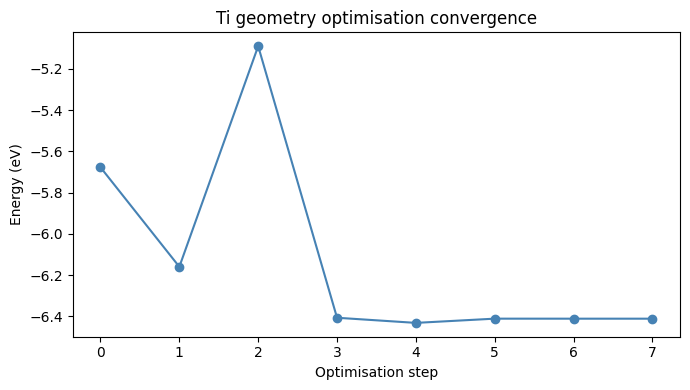

In [83]:
# Plot the energy convergence during optimisation
import matplotlib.pyplot as plt

traj = Trajectory('/tmp/Ti_opt.traj')
energies = [atoms.get_potential_energy() for atoms in traj]
plt.figure(figsize=(7, 4))
plt.plot(energies, 'o-', color='steelblue')
plt.xlabel('Optimisation step')
plt.ylabel('Energy (eV)')
plt.title('Ti geometry optimisation convergence')
plt.tight_layout()
plt.show()


### Exercise: Just Relax

Find a material on the MaterialsProject and use DFT to relax it. The computational cost scales with $n**3$ (where $n$ is the number of atoms); so, you may want to find relatively simple materials (with one or two atoms in a unit cell).

## K-point convergence


## Key Points

- Geometry optimisation finds the minimum energy atomic configuration
- **BFGS** is the standard choice; **FIRE** can be better for large systems
- `FixAtoms` constrains selected atoms during optimisation
- Convergence criterion `fmax` is the maximum force component (typically 0.01–0.05 eV/Å for DFT)
- Defect supercell relaxation is **essential** before computing electronic or optical properties

## Exercise 8.1

Build a 2×2×2 supercell of wurtzite GaN and introduce a nitrogen vacancy (V_N) by deleting one N atom. Relax the structure with BFGS using EMT. By how much does the nearest Ga atom move inward toward the vacancy? (This "breathing mode" relaxation is a characteristic signature of point defects.)

## Exercise 8.2

Look up the concept of the **configuration coordinate diagram** (CCD). How is it related to geometry optimisation in the ground and excited states? Sketch a CCD for the NV centre, labelling the zero-phonon line (ZPL) energy, the Stokes shift, and the reorganisation energy.


## Exercise 6.3 — Coursework Preparation: Relaxing Your Defect Structure

1. Load your `coursework_defect_initial.xyz` from Tutorial 4.
2. Attach the MACE-MP-0 calculator (from Tutorial 8) and relax the structure with BFGS 
   (fmax = 0.01 eV/Å).
3. Plot the convergence of the maximum force vs optimisation step.
4. Save the relaxed structure as `coursework_defect_relaxed.xyz`.

Answer these questions in a markdown cell:
- How many steps did relaxation take? Is this more or less than you expected?
- By how much did the atoms nearest the defect move (in Å)?  
- Does the relaxed structure preserve the expected point symmetry of the defect?

This relaxed geometry is the starting point for your DFT electronic structure calculation.

*Note: If MACE is not yet installed, use EMT as a placeholder and revisit after Tutorial 8.*
